In [11]:
import numpy as np
import pyvisa as visa
from labrad.server import LabradServer, setting
import time
import sys 
sys.path.append('utility/')
from gatedict import gatedict


import matplotlib.pyplot as plt


In [12]:
#replace single pulse with gatedict
nor=1000
drive_time = 280
phase = 0

total_time = np.ceil((drive_time)/(1000/nor))
print(total_time)
cycle_time_nor = 25/(1000/nor)
time_nor = 1/(1000/nor)
gatearray = np.zeros(int(total_time))
gatearray = np.cos(2*np.pi*.08/time_nor*np.arange(0,int(total_time),1)+phase)
gatearray[-1] = 0

280.0


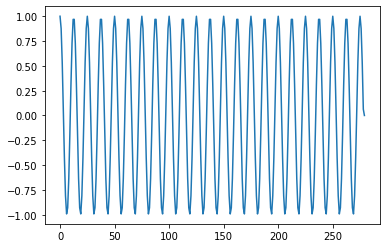

In [13]:
plt.plot(gatearray)

In [4]:
total_time = int(np.ceil((drive_time)/(1000/nor)))
print(total_time)
pt = np.linspace(0,total_time-1,total_time)
gatearray_1 = gatedict.gatedict["sigma"](0,pt)
gatearray_1[-1] = 0

280


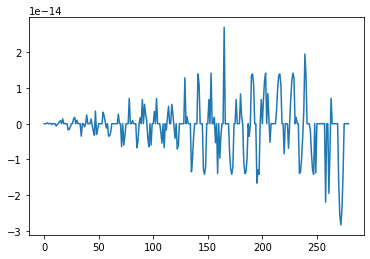

In [5]:
plt.plot(gatearray_1-gatearray)

In [6]:
total_time = int(np.ceil((drive_time)/(1000/nor)))
time_nor = 1/(1000/nor)
#set alpha for tukey pulse
alpha = 0.3
l=int(alpha*drive_time)
gatearray = np.zeros(total_time)
#print(l,total_time)
gatearray[:l] = 1/2*(1-np.cos(np.pi*np.arange(0,l,1)/(l)))*np.cos(2*np.pi*np.arange(0,l,1)*.08/time_nor+phase)
gatearray[l:-l] = np.cos(2*np.pi*np.arange(l,total_time-l,1)*.08/time_nor+phase)
gatearray[-l:] = 1/2*(1-np.cos(np.pi*np.arange(l,0,-1)/(l)))*np.cos(2*np.pi*np.arange(total_time-l,total_time,1)*.08/time_nor+phase)
gatearray[total_time-1] = 0

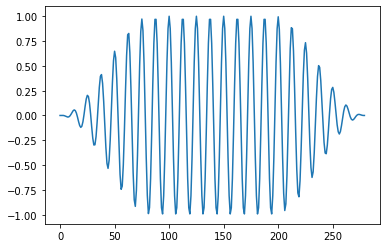

In [7]:
plt.plot(gatearray)

In [8]:
total_time = int(np.ceil((drive_time)/(1000/nor)))
print(total_time)
pt = np.linspace(0,total_time-1,total_time)
gatearray_1 = gatedict.gatedict["sigmatukey"](0,pt)
gatearray_1[-1] = 0

280


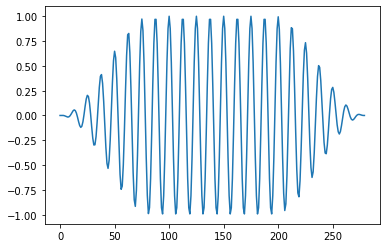

In [9]:
plt.plot(gatearray_1)

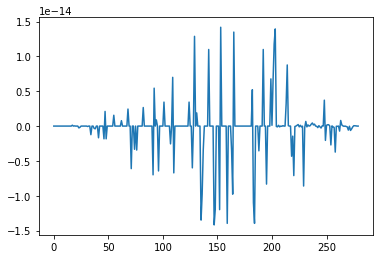

In [10]:
plt.plot(gatearray_1-gatearray)

280


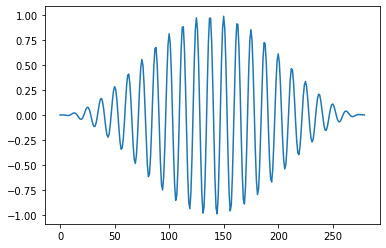

In [12]:
total_time = int(np.ceil((drive_time)/(1000/nor)))
print(total_time)
pt = np.linspace(0,total_time-1,total_time)
gatearray_1 = gatedict.gatedict["sigmahann"](0,pt)
gatearray_1[-1] = 0
plt.plot(gatearray_1)

280


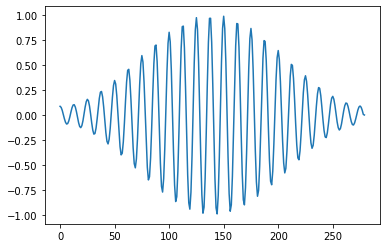

In [13]:
total_time = int(np.ceil((drive_time)/(1000/nor)))
print(total_time)
pt = np.linspace(0,total_time-1,total_time)
gatearray_1 = gatedict.gatedict["sigmahamming"](0,pt)
gatearray_1[-1] = 0
plt.plot(gatearray_1)

In [36]:
half_pi_time = 110
pi_time = 260
spacing = 0
total_time = int(np.ceil((2*half_pi_time+pi_time+2*spacing)/(1000/nor)))
print(total_time)


gatearray = np.zeros(int(total_time))
alpha = 0.3

t_val_1 = int(np.ceil((half_pi_time)*time_nor))
#gatearray[:t_val_1] = np.cos(2*np.pi*.08/time_nor*np.arange(0,t_val_1,1))
l=int(alpha*t_val_1)
#print(l,total_time)
gatearray[:l] = 1/2*(1-np.cos(np.pi*np.arange(0,l,1)/(l)))*np.cos(2*np.pi*np.arange(0,l,1)*.08/time_nor)
gatearray[l:t_val_1-l] = np.cos(2*np.pi*np.arange(l,t_val_1-l,1)*.08/time_nor)
gatearray[t_val_1-l:t_val_1] = 1/2*(1-np.cos(np.pi*np.arange(l,0,-1)/(l)))*np.cos(2*np.pi*np.arange(t_val_1-l,t_val_1,1)*.08/time_nor)

#gatearray[:t_val_1] = np.cos(2*np.pi*.08/time_nor*np.arange(0,t_val_1,1))
#l=int(alpha*t_val_1)
#print(l,total_time)
# gatearray[t_val_1:t_val_1+l] = 1/2*(1-np.cos(np.pi*np.arange(0,l,1)/(l)))*np.cos(2*np.pi*np.arange(t_val_1,t_val_1+l,1)*.08/time_nor)
# gatearray[t_val_1+l:t_val_1*2-l] = np.cos(2*np.pi*np.arange(t_val_1+l,t_val_1+t_val_1-l,1)*.08/time_nor)
# gatearray[t_val_1*2-l:t_val_1*2] = 1/2*(1-np.cos(np.pi*np.arange(l,0,-1)/(l)))*np.cos(2*np.pi*np.arange(t_val_1+t_val_1-l,t_val_1+t_val_1,1)*.08/time_nor)




t_val_2 = int(np.ceil((half_pi_time+pi_time+spacing)*time_nor))
#gatearray[t_val_1:t_val_2] = np.sin(2*np.pi*.08/time_nor*np.arange(t_val_1,t_val_2,1))
l=int(alpha*(t_val_2-t_val_1))
#print(l,total_time)
gatearray[t_val_1:t_val_1+l] = 1/2*(1-np.cos(np.pi*np.arange(0,l,1)/(l)))*np.sin(2*np.pi*np.arange(t_val_1,t_val_1+l,1)*.08/time_nor)
gatearray[t_val_1+l:t_val_2-l] = np.sin(2*np.pi*np.arange(t_val_1+l,t_val_2-l,1)*.08/time_nor)
gatearray[t_val_2-l:t_val_2] = 1/2*(1-np.cos(np.pi*np.arange(l,0,-1)/(l)))*np.sin(2*np.pi*np.arange(t_val_2-l,t_val_2,1)*.08/time_nor)

#gatearray[t_val_2:] = np.cos(2*np.pi*.08/time_nor*np.arange(t_val_2,total_time,1))
l=int(alpha*(total_time-t_val_2))
#print(l,total_time)
gatearray[t_val_2:t_val_2+l] = 1/2*(1-np.cos(np.pi*np.arange(0,l,1)/(l)))*np.cos(2*np.pi*np.arange(t_val_2,t_val_2+l,1)*.08/time_nor)
print(t_val_2+l,total_time-l)
gatearray[t_val_2+l:total_time-l] = np.cos(2*np.pi*np.arange(t_val_2+l,total_time-l,1)*.08/time_nor)
gatearray[total_time-l:] = 1/2*(1-np.cos(np.pi*np.arange(l,0,-1)/(l)))*np.cos(2*np.pi*np.arange(total_time-l,total_time,1)*.08/time_nor)

amp_nor = 1.0
gatearray[t_val_1:] = gatearray[t_val_1:]*amp_nor
gatearray[t_val_1:t_val_1+spacing] = 0
gatearray[t_val_2:t_val_2+spacing] = 0
gatearray[-1] = 0

480
403 447


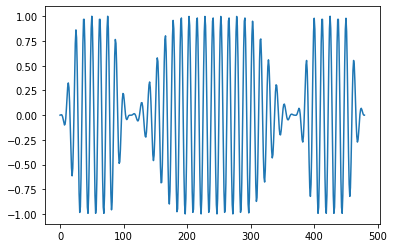

In [37]:
plt.plot(gatearray)

In [38]:
total_time = int(np.ceil((2*half_pi_time+pi_time+2*spacing)/(1000/nor)))
print(total_time)
gatearray_1 = np.zeros(total_time)

t_val_1 = int(np.ceil((half_pi_time)*time_nor))
gatearray_1[:t_val_1] = gatedict.gatedict["sigmatukey"](0,np.arange(0,t_val_1,1))

t_val_2 = int(np.ceil((half_pi_time+pi_time+spacing)*time_nor))
gatearray_1[t_val_1:t_val_2] = gatedict.gatedict["sigmatukey"](-np.pi/2+2*np.pi*t_val_1*.08/time_nor,np.arange(0,t_val_2-t_val_1,1))

gatearray_1[t_val_2:] = gatedict.gatedict["sigmatukey"](2*np.pi*t_val_2*.08/time_nor,np.arange(0,t_val_1))


gatearray_1[t_val_1:t_val_1+spacing] = 0
gatearray_1[t_val_2:t_val_2+spacing] = 0
gatearray_1[-1] = 0


gatearray_1[t_val_1:t_val_1+spacing] = 0
gatearray_1[t_val_2:t_val_2+spacing] = 0
gatearray_1[-1] = 0

480


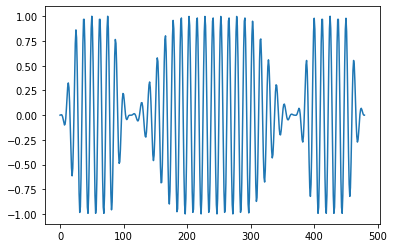

In [39]:
plt.plot(gatearray_1)

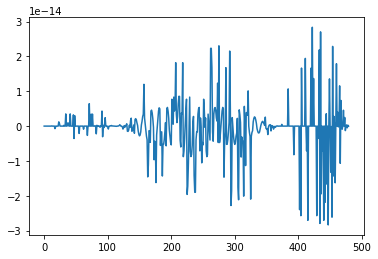

In [18]:
plt.plot(gatearray-gatearray_1)
#gatearray[-1]-gatearray_1[-1]

In [89]:
import numpy as _np
from labrad.units import WithUnit
def compile_gates(gate_list = None):
    nor=1000
    """Using the direct AWG output to generate a gate sequence with single and two-qubit gates\n
    channel (int): channel number\n
    amplitudes (Volts): the amplitude of MS\n
    repetition (int): the number of times for this sequence to repeat (with a new trigger)\n
    gate_list [[start_time(us),duration(us), gate1_specified], [start_time,duration, gate2_specified], ..]: gate sequence\n
    avaliable gates:\n
    sigma_phi(float in degs): single qubit gate: e.g. sigma_y: sigma_90\n
    sigmatukey_phi(float in degs): single qubit gate with tukey pulseshaping(a=0.3): e.g. sigmatukey_y: sigma_90\n
    phiphi_phi_mu(MHz)_r1_r2: two qubit gate: e.g. xx MS with mu=1.2MHz and equal strength for bsb and rsb: phiphi_0_1.2_1_1\n
    phiphitukey_phi_mu(MHz)_r1_r2_a: two qubit gate with tukey pulseshaping: e.g. yy MS with mu=1.2MHz and a=0.1 tukey: phiphitukey_90_1.2_1_1_0.1\n
    """
    #we specify gates by using the format of (start_time, duration) and for the start time and duration, there can be two different units
    #1. In the units of regular time s.t. WithUnit(n,'us'). BUT note that n must be divisible by 8. Otherwise we will have an error
    #2. In the units of pi time s.t. WithUnit(n,'pi-time'). This is used for single qubit gates and n can be floats
    
    #first we get total time for the sequence: in units of pi time(2.5us)/actual time + n* 4cycle of 125MHz time (8ns) for n number of gates
    #we also check if the time is implemented correctly
    gate_time_nor = 2504/(1000/nor)
    cycle_time_nor = 8/(1000/nor)
    time_nor = 1/(1000/nor)
    gate_list = _np.array(gate_list)
    #print(type(gate_list))
    #we will replace the original input list to an array with normalized time
    

    #we need an offset array to count the offsets of every starttime due to rounding
    #Note offset[i] is the offset before ith layer
    #offset[0] = 0 always
    offset = _np.zeros(len(gate_list)+1)

    for i in range(len(gate_list)):
        start_time = gate_list[i][0]['ns']
        duration = gate_list[i][1]['ns']
        # #print(start_time,duration, time_nor)
        # start_time = _np.ceil(start_time['ns']) * time_nor + offset[i]
        # r = _np.round(_np.remainder(start_time, cycle_time_nor))
        # if r < 0.005 or r > cycle_time_nor - 0.005:
        #     r = 0
        #     #print(r)
        # else:
        #     #pass
        #     r = cycle_time_nor - r
        #     #print(r)
        # offset[i] += r
        # start_time += r
        
        # duration = _np.ceil(duration['ns']) * time_nor
        # r = _np.round(_np.remainder(duration, cycle_time_nor))
        # if r < 0.005 or r > cycle_time_nor - 0.005:
        #     r = 0
        #     #print(r)
        # else:
        #     r = cycle_time_nor - r
        #     #pass
        # #    print(r)
        # offset[i] += r
        # offset[i+1] += offset[i]
        gate_list[i][0] = start_time
        gate_list[i][1] = duration
        #print(start_time,duration)
        """
        #Note: THis is a risky move as we add pi-time as a unit in the labrad.units file

        if start_time.units == 'pi-time':
            start_time = start_time['pi-time'] * gate_time_nor
        else:
            start_time = start_time['ns'] * time_nor
        #first check if the divisible things make sense
        r = _np.abs(_np.remainder(start_time, cycle_time_nor))
        if r < 0.005 or r > cycle_time_nor - 0.005:
            pass
        else:
            print(r)
            raise Exception("wrong gate start time")
        gate_list[i][0] = start_time
        
        if duration == 'pi-time':
            duration = duration['pi-time'] * gate_time_nor
        else:
            duration = duration['ns'] * time_nor
        r = _np.abs(_np.remainder(duration, cycle_time_nor))
        if r < 0.005 or r > cycle_time_nor - 0.005:
            pass
        else:
            print(r)
            raise Exception("wrong gate duration time")
        gate_list[i][1] = duration
        """
        
    total_time = (gate_list[-1][0]+gate_list[-1][1])+len(gate_list)*4*cycle_time_nor
    total_time = int(_np.ceil(total_time))


    wf = _np.zeros(total_time)
    #we need a time_counter to make sure there is no overlap
    time_counter = 0
    for gate_index in range(len(gate_list)):
        gate_start,gate_duration,gate_type = gate_list[gate_index]
        gate_duration = int(_np.round(gate_duration))
        #normalize gate time and gate start time
        #print(gate_start+gate_index*4*cycle_time_nor,gate_duration+4*cycle_time_nor)
        gate_start = int(_np.round(gate_start+gate_index*4*cycle_time_nor))
        gate_duration = int(_np.round(gate_duration+4*cycle_time_nor))
        if gate_start >= time_counter:
            time_counter = gate_start+gate_duration
        else:
            
            raise Exception("gate sequence time not specifying correclty")

        #calculate the gate

        pt = _np.linspace(0,gate_duration-1,gate_duration)
        #now we need to make the gate 
        gate = gate_type.split("_")
        #single qubit gate: gatename, phi
        if len(gate)==2:
            gate_phi = int(gate[1])/180*_np.pi
            start_time_phi = 2*_np.pi*gate_list[i][0]*.08/time_nor
            
            #print(gate_phi)
            gate = gate[0]
            wf[gate_start:gate_start+gate_duration] = gatedict.gatedict[gate](gate_phi+start_time_phi,pt)

        else:
            gate = gate[0]
            wf[gate_start:gate_start+gate_duration] = gatedict.gatedict[gate](pt)
         
    
    return wf

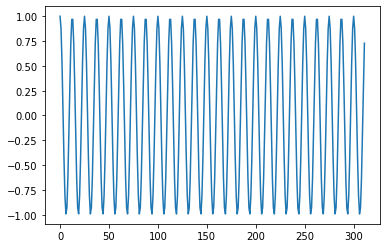

In [97]:
half_pi_time = 110
pi_time = 260

gate_list_2 = [[WithUnit(0,'ns'),WithUnit(drive_time,'ns'),"sigma_0"]]
gatearray_2 = compile_gates(gate_list_2)
plt.plot(gatearray_2)

In [ ]:
total_time = int(np.ceil((drive_time)/(1000/nor)))
print(total_time)
pt = np.linspace(0,total_time-1,total_time)
gatearray_1 = gatedict.gatedict["sigma"](0,pt)
#gatearray_1[-1] = 0

280


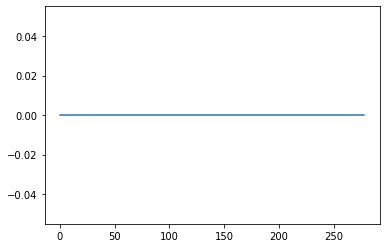

In [ ]:
plt.plot(gatearray_1[:]-gatearray_2[:-33])
#gatearray[-1]-gatearray_1[-1]